# SentinelHub

SentinelHub is a hosted service.

In [8]:
import pickle
import datetime
from sentinelhub import (
    CRS,
    BBox,
    DataCollection,
    MimeType,
    SentinelHubDownloadClient,
    SentinelHubRequest,
    SHConfig,
    SentinelHubSession,
)
import pystac_client

In [9]:
with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)

bbox_sh = BBox(p["box_3035"].bounds, CRS(3035))

In [10]:
config = SHConfig("download")
session = SentinelHubSession(
    config=config,
)

URL = "https://stac.dataspace.copernicus.eu/v1"
cat = pystac_client.Client.open(URL)
cat.add_conforms_to("ITEM_SEARCH")

In [5]:
params = {
    "limit": 100,
    "collections": "sentinel-2-l2a",
    "datetime": f"{p['start'].strftime('%Y-%m-%d')}/{p['end'].strftime('%Y-%m-%d')}",
    "bbox": p["box_4326"].bounds,
    "query": {"eo:cloud_cover": {"lte": 80}},
    "sortby": "properties.eo:cloud_cover",
    "fields": {"exclude": ["geometry"]},
}
stac_items = list(cat.search(**params).item_collection())

In [6]:
evalscript_single_band = """//VERSION=3

bands = ["B03", "B11", "SCL"]

function setup() {
    return {
        input: [{
                bands: bands,
                units: "DN"
            }],
        output: {
            bands: bands.length,
            sampleType: "UINT16"

        },
        mosaicking: "SIMPLE"
    }
}

function evaluatePixel(samples) {
    return bands.map(band => samples[band]);
}
"""

In [7]:
def get_request(time_interval):
    return SentinelHubRequest(
        evalscript=evalscript_single_band,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A.define_from(
                    "s2", service_url=config.sh_base_url
                ),
                time_interval=time_interval,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox=bbox_sh,
        resolution=(10, 10),
        config=config,
        data_folder="./data",
    )

In [8]:
acquisitions_dates = [
    datetime.datetime.fromisoformat(stac_item.properties["datetime"]).strftime(
        "%Y-%m-%d"
    )
    for stac_item in stac_items
]
requests = [get_request((date, date)) for date in acquisitions_dates]

In [22]:
list_of_requests = [request.download_list[0] for request in requests]

# download data with multiple threads
data = SentinelHubDownloadClient(config=config).download(
    list_of_requests, max_threads=5
)

# Lazy datacube via `sh_datacube.load`

The exploration above is wrapped into `sh_datacube.py`. It queries the SH
Catalog for acquisition days, builds a single multi-band evalscript (one
request per timestamp), and returns a lazy dask-backed `xarray.DataArray` with
dims `(time, band, y, x)`.

Bands are a **dimension**, not separate variables: one Process API request
returns all bands as a single `(y, x, band)` array, so the natural dask chunk is
`(1, n_bands, y, x)`. One request also means one output `sampleType`, so the
smallest dtype that fits every requested band is chosen automatically (DN-only
S2 → `UINT16`; add e.g. `sunAzimuthAngles` → `FLOAT32`). Use
`.to_dataset(dim="band")` if you want one variable per band.

In [11]:
from sh_datacube import load
import dask

dask.config.set(scheduler="threads", num_workers=8)

cube = load(
    DataCollection.SENTINEL2_L2A,
    bands=["B03", "B11", "SCL"],
    bbox=bbox_sh,  # BBox in EPSG:3035 from the params above
    time=(p["start"].strftime("%Y-%m-%d"), p["end"].strftime("%Y-%m-%d")),
    # time=("2022-01-01", "2023-01-01"),
    resolution=10,
    max_cloud_cover=80,
    config=config,
).to_dataset(dim="band")
# lazy: nothing downloaded yet, one request per timestamp

In [12]:
%%time
# Compute with threads: each timestamp is an independent request, so this is
# I/O bound and scales well with the thread count.
computed = cube.compute(scheduler="threads", num_workers=8)

CPU times: total: 7.5 s
Wall time: 20.4 s


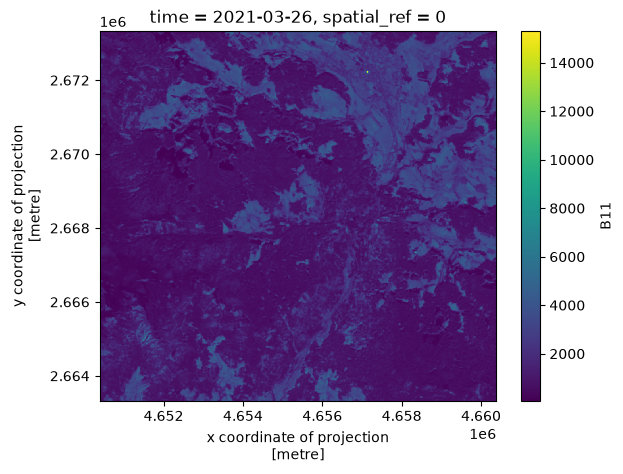

In [14]:
computed.B11.isel(time=22).plot();